### ANÁLISIS DE DATOS DEL SISTEMA ECOBICI EN LA CIUDAD DE MÉXICO DEL AÑO 2012
Este análisis fue realizado utilizando pyspark SQL haciendo manejo de DataFrames y DataFrames temporales para evitar alterar la estructura de los DF iniciales y normalizados.
1) Obtención de archivos CSV del clúster HADOOP con "read.csv" (previamente descargados con CURL -L al clúster en terminal)
2) Normalización de datos de horas de retiro en HH:MM:SS
3) Segmentación de DataFrame principal en más pequeños para agilizar las consultas (Datos de retiro y Datos de arribo de bicicletas)
4) Agregar columnas de años, meses, días y horas, minutos y segundos para consultas específicas y ejercicio personal de división de datos.
5) Guardado de DataFrames y creación de tablas temporales para modificarlas a comodidad.
6) Consultas
   a) 10 estaciones con mayor demanda de inicio

   b) 5 horas del día con mayor demanda

   c) Día de la semana con menor demanda

   d) Estadísticas descriptivas (Promedio de edad, edad mínima y máxima, desviación estándar)

   e) Estadísticas descriptivas (Total de viajes por género, edades distintas, edad promedio por género, edad mínima y máxima y desviación estándar)

   f)Cantidad de bicicletas totales

   g) viajes por género (graficación)

   h) Horas pico de uso (graficación)

   i) viajes por edad de usuario (gráficación)

   j) comparativa de viajes por grupo de edad y género (graficación)

   k) viajes por mes (graficación de tendencias a lo largo del año)


In [1]:
#importacion de librerias para poder trabajar los datos
from pyspark.sql.functions import col, sum, to_date, to_timestamp, regexp_replace, date_format
from pyspark.sql.types import IntegerType, DoubleType, FloatType

#### 1) Obtención de archivos CSV del clúster HADOOP con "read.csv" (previamente descargados con CURL -L al clúster en terminal)

In [2]:
#1)
dir_hdfs = "hdfs://namenode:9000/tmp/amd/ecobici_2012"

In [3]:
#Creación del dataframe principal
df = spark.read.csv(f"{dir_hdfs}/*.csv", header = True, inferSchema = True)

In [4]:
#revisión del esquema de DF para observar el tipo de los datos dentro del DF
df.printSchema()

root
 |-- Genero_Usuario: string (nullable = true)
 |-- Edad_Usuario: integer (nullable = true)
 |-- Bici: integer (nullable = true)
 |-- Ciclo_Estacion_Retiro: integer (nullable = true)
 |-- Fecha_Retiro: date (nullable = true)
 |-- Hora_Retiro: timestamp (nullable = true)
 |-- Ciclo_Estacion_Arribo: integer (nullable = true)
 |-- Fecha_Arribo: date (nullable = true)
 |-- Hora_Arribo: timestamp (nullable = true)



In [5]:
#Numeración de elementos de DF (NO RECOMENDADO EN DF MÁS GRANDES)
print(f"Numero de renglones: {df.count()}")
print(f"Numero de columnas :{len(df.columns)}")
print(f"Columnas: {df.columns}")

Numero de renglones: 2737917
Numero de columnas :9
Columnas: ['Genero_Usuario', 'Edad_Usuario', 'Bici', 'Ciclo_Estacion_Retiro', 'Fecha_Retiro', 'Hora_Retiro', 'Ciclo_Estacion_Arribo', 'Fecha_Arribo', 'Hora_Arribo']


In [6]:
df.show(5, truncate = False)

+--------------+------------+----+---------------------+------------+-----------------------+---------------------+------------+-------------------+
|Genero_Usuario|Edad_Usuario|Bici|Ciclo_Estacion_Retiro|Fecha_Retiro|Hora_Retiro            |Ciclo_Estacion_Arribo|Fecha_Arribo|Hora_Arribo        |
+--------------+------------+----+---------------------+------------+-----------------------+---------------------+------------+-------------------+
|M             |30          |1667|63                   |2012-11-01  |2026-03-18 00:00:10.72 |132                  |2012-11-01  |2026-03-18 00:21:23|
|M             |35          |2710|27                   |2012-11-01  |2026-03-18 00:01:10.847|128                  |2012-11-01  |2026-03-18 00:08:15|
|F             |45          |289 |67                   |2012-11-01  |2026-03-18 00:01:12.813|74                   |2012-11-01  |2026-03-18 00:04:04|
|M             |24          |1050|106                  |2012-11-01  |2026-03-18 00:01:43.017|106          

#### 2) Normalización de datos de horas de retiro y arribo en HH:MM:SS

In [7]:
#Existe 
df = df.withColumn("Hora_Retiro", date_format(col("Hora_Retiro"), "HH:mm:ss"))\
.withColumn("Hora_Arribo", date_format(col("Hora_Arribo"), "HH:mm:ss"))
df.show(5, truncate=False)

+--------------+------------+----+---------------------+------------+-----------+---------------------+------------+-----------+
|Genero_Usuario|Edad_Usuario|Bici|Ciclo_Estacion_Retiro|Fecha_Retiro|Hora_Retiro|Ciclo_Estacion_Arribo|Fecha_Arribo|Hora_Arribo|
+--------------+------------+----+---------------------+------------+-----------+---------------------+------------+-----------+
|M             |30          |1667|63                   |2012-11-01  |00:00:10   |132                  |2012-11-01  |00:21:23   |
|M             |35          |2710|27                   |2012-11-01  |00:01:10   |128                  |2012-11-01  |00:08:15   |
|F             |45          |289 |67                   |2012-11-01  |00:01:12   |74                   |2012-11-01  |00:04:04   |
|M             |24          |1050|106                  |2012-11-01  |00:01:43   |106                  |2012-11-01  |00:20:01   |
|M             |23          |2733|222                  |2012-11-01  |00:01:57   |54              

#### 3) Segmentación de DataFrame principal haciendo selección de columnas para agilizar las consultas (Datos de retiro y Datos de arribo de bicicletas).

In [8]:
datos_retiro = df.select(['Genero_Usuario','Edad_Usuario', 'Bici','Ciclo_Estacion_Retiro',
                         'Fecha_Retiro','Hora_Retiro'])
datos_retiro.show(5)
datos_retiro.printSchema()

+--------------+------------+----+---------------------+------------+-----------+
|Genero_Usuario|Edad_Usuario|Bici|Ciclo_Estacion_Retiro|Fecha_Retiro|Hora_Retiro|
+--------------+------------+----+---------------------+------------+-----------+
|             M|          30|1667|                   63|  2012-11-01|   00:00:10|
|             M|          35|2710|                   27|  2012-11-01|   00:01:10|
|             F|          45| 289|                   67|  2012-11-01|   00:01:12|
|             M|          24|1050|                  106|  2012-11-01|   00:01:43|
|             M|          23|2733|                  222|  2012-11-01|   00:01:57|
+--------------+------------+----+---------------------+------------+-----------+
only showing top 5 rows

root
 |-- Genero_Usuario: string (nullable = true)
 |-- Edad_Usuario: integer (nullable = true)
 |-- Bici: integer (nullable = true)
 |-- Ciclo_Estacion_Retiro: integer (nullable = true)
 |-- Fecha_Retiro: date (nullable = true)
 |-- Hor

In [9]:
datos_arribo = df.select(['Genero_Usuario','Edad_Usuario', 'Bici','Ciclo_Estacion_Arribo',
                         'Fecha_Arribo','Hora_Arribo'])
datos_arribo.show(5)
datos_arribo.printSchema()

+--------------+------------+----+---------------------+------------+-----------+
|Genero_Usuario|Edad_Usuario|Bici|Ciclo_Estacion_Arribo|Fecha_Arribo|Hora_Arribo|
+--------------+------------+----+---------------------+------------+-----------+
|             M|          30|1667|                  132|  2012-11-01|   00:21:23|
|             M|          35|2710|                  128|  2012-11-01|   00:08:15|
|             F|          45| 289|                   74|  2012-11-01|   00:04:04|
|             M|          24|1050|                  106|  2012-11-01|   00:20:01|
|             M|          23|2733|                   54|  2012-11-01|   00:21:33|
+--------------+------------+----+---------------------+------------+-----------+
only showing top 5 rows

root
 |-- Genero_Usuario: string (nullable = true)
 |-- Edad_Usuario: integer (nullable = true)
 |-- Bici: integer (nullable = true)
 |-- Ciclo_Estacion_Arribo: integer (nullable = true)
 |-- Fecha_Arribo: date (nullable = true)
 |-- Hor

#### 4) Agregar columnas de años, meses, días y horas, minutos y segundos para consultas específicas y ejercicio personal de división de datos.

In [10]:
from pyspark.sql.functions import hour,minute,second,year,month,dayofmonth,weekofyear
#se realiza referencia a los nombres de las columnas para no escribir su nombre
#completo de nuevo
fr = "Fecha_Retiro"
hr = "Hora_retiro"
#se añade año mes dia hora minuto segundo dia semana en df retiro
df_tiempo_retiro = datos_retiro.select(
    col("Genero_Usuario"), col("Edad_Usuario"),col("Bici"), col("Ciclo_Estacion_Retiro"),
    year(col(fr)).alias("anio_retiro"),
    month(col(fr)).alias("mes_retiro"),
    dayofmonth(col(fr)).alias("dia_semana_retiro"),
    weekofyear(col(fr)).alias("semana_retiro"),
    date_format(col(fr),"EEEE").alias("nombre_dia_retiro"),
    date_format(col(fr),"MMMM").alias("nombre_mes_retiro"),
    hour(col(hr)).alias("hora_retiro"),
    minute(col(hr)).alias("minuto_retiro"),
    second(col(hr)).alias("segundo_retiro")
)

df_tiempo_retiro.show(5,truncate=False)


+--------------+------------+----+---------------------+-----------+----------+-----------------+-------------+-----------------+-----------------+-----------+-------------+--------------+
|Genero_Usuario|Edad_Usuario|Bici|Ciclo_Estacion_Retiro|anio_retiro|mes_retiro|dia_semana_retiro|semana_retiro|nombre_dia_retiro|nombre_mes_retiro|hora_retiro|minuto_retiro|segundo_retiro|
+--------------+------------+----+---------------------+-----------+----------+-----------------+-------------+-----------------+-----------------+-----------+-------------+--------------+
|M             |30          |1667|63                   |2012       |11        |1                |44           |Thursday         |November         |0          |0            |10            |
|M             |35          |2710|27                   |2012       |11        |1                |44           |Thursday         |November         |0          |1            |10            |
|F             |45          |289 |67                   

In [11]:
#se realiza referencia a los nombres de las columnas para no escribir su nombre
#completo de nuevo
fr = "Fecha_Arribo"
hr = "Hora_Arribo"
#se añade año mes dia hora minuto segundo dia semana en df arribo
df_tiempo_arribo = datos_arribo.select(
    col("Genero_Usuario"), col("Edad_Usuario"),col("Bici"), col("Ciclo_Estacion_Arribo"),
    year(col(fr)).alias("anio_arribo"),
    month(col(fr)).alias("mes_arribo"),
    dayofmonth(col(fr)).alias("dia_semana_arribo"),
    weekofyear(col(fr)).alias("semana_arribo"),
    date_format(col(fr),"EEEE").alias("nombre_dia_arribo"),
    date_format(col(fr),"MMMM").alias("nombre_mes_arribo"),
    hour(col(hr)).alias("hora_arribo"),
    minute(col(hr)).alias("minuto_arribo"),
    second(col(hr)).alias("segundo_arribo")
)

df_tiempo_arribo.show(5,truncate=False)

+--------------+------------+----+---------------------+-----------+----------+-----------------+-------------+-----------------+-----------------+-----------+-------------+--------------+
|Genero_Usuario|Edad_Usuario|Bici|Ciclo_Estacion_Arribo|anio_arribo|mes_arribo|dia_semana_arribo|semana_arribo|nombre_dia_arribo|nombre_mes_arribo|hora_arribo|minuto_arribo|segundo_arribo|
+--------------+------------+----+---------------------+-----------+----------+-----------------+-------------+-----------------+-----------------+-----------+-------------+--------------+
|M             |30          |1667|132                  |2012       |11        |1                |44           |Thursday         |November         |0          |21           |23            |
|M             |35          |2710|128                  |2012       |11        |1                |44           |Thursday         |November         |0          |8            |15            |
|F             |45          |289 |74                   

#### 5) Guardado de DataFrames y creación de tablas temporales para modificarlas a comodidad.

In [12]:
df.write.mode("overwrite").option("header","true").csv
("hdfs://namenode:9000/tmp/amd/ecobicilimpio1");
df_tiempo_retiro.write.mode("overwrite").option("header","true").csv
("hdfs://namenode:9000/tmp/amd/ecobici_retiro");
df_tiempo_arribo.write.mode("overwrite").option("header","true").csv
("hdfs://namenode:9000/tmp/amd/ecobici_arribo");
#los puntosycomas (;) en este caso son para que no exista outputs (o salida) de esta celda

In [13]:
df.createOrReplaceTempView("ECOBICI")
df_tiempo_retiro.createOrReplaceTempView("ECOBICI_retiro")
df_tiempo_arribo.createOrReplaceTempView("ECOBICI_arribo")

In [14]:
spark.sql("show tables").show()

+---------+--------------+-----------+
|namespace|     tableName|isTemporary|
+---------+--------------+-----------+
|         |       ecobici|       true|
|         |ecobici_arribo|       true|
|         |ecobici_retiro|       true|
+---------+--------------+-----------+



In [15]:
spark.sql("describe ecobici").show()

+--------------------+---------+-------+
|            col_name|data_type|comment|
+--------------------+---------+-------+
|      Genero_Usuario|   string|   NULL|
|        Edad_Usuario|      int|   NULL|
|                Bici|      int|   NULL|
|Ciclo_Estacion_Re...|      int|   NULL|
|        Fecha_Retiro|     date|   NULL|
|         Hora_Retiro|   string|   NULL|
|Ciclo_Estacion_Ar...|      int|   NULL|
|        Fecha_Arribo|     date|   NULL|
|         Hora_Arribo|   string|   NULL|
+--------------------+---------+-------+



In [16]:
spark.sql("describe ecobici_retiro").show()
spark.sql("describe ecobici_arribo").show()

+--------------------+---------+-------+
|            col_name|data_type|comment|
+--------------------+---------+-------+
|      Genero_Usuario|   string|   NULL|
|        Edad_Usuario|      int|   NULL|
|                Bici|      int|   NULL|
|Ciclo_Estacion_Re...|      int|   NULL|
|         anio_retiro|      int|   NULL|
|          mes_retiro|      int|   NULL|
|   dia_semana_retiro|      int|   NULL|
|       semana_retiro|      int|   NULL|
|   nombre_dia_retiro|   string|   NULL|
|   nombre_mes_retiro|   string|   NULL|
|         hora_retiro|      int|   NULL|
|       minuto_retiro|      int|   NULL|
|      segundo_retiro|      int|   NULL|
+--------------------+---------+-------+

+--------------------+---------+-------+
|            col_name|data_type|comment|
+--------------------+---------+-------+
|      Genero_Usuario|   string|   NULL|
|        Edad_Usuario|      int|   NULL|
|                Bici|      int|   NULL|
|Ciclo_Estacion_Ar...|      int|   NULL|
|         anio_

#### 6) Consultas


#####  a) 10 estaciones con mayor demanda de inicio


In [17]:
#se utiliza la variable con triples comillas para escribir de
#manera legible las querys de sql
strsql="""
SELECT Ciclo_Estacion_Retiro AS estacion_inicio, COUNT(*) AS num_viajes
FROM ecobici_retiro
GROUP BY Ciclo_Estacion_Retiro
ORDER BY num_viajes DESC
LIMIT 10
"""
spark.sql(strsql).show(truncate=False)

+---------------+----------+
|estacion_inicio|num_viajes|
+---------------+----------+
|36             |58881     |
|27             |56857     |
|1              |55942     |
|64             |54646     |
|41             |52026     |
|13             |45488     |
|85             |44145     |
|18             |43521     |
|84             |42217     |
|21             |39311     |
+---------------+----------+



##### b) 5 horas del día con mayor demanda

In [18]:
strsql="""
SELECT HOUR(Hora_Retiro) AS hora, COUNT (*) AS num_viajes
FROM ecobici
GROUP BY HOUR(Hora_retiro)
ORDER BY num_viajes DESC
LIMIT 5
"""
spark.sql(strsql).show(truncate=False)

+----+----------+
|hora|num_viajes|
+----+----------+
|18  |234658    |
|8   |222619    |
|14  |220045    |
|19  |217117    |
|15  |210520    |
+----+----------+



##### c) Día de la semana con menor demanda

Esta versión es para observar el número del día utilizando el DataFrame "ECOBICI" (con info de retiros y arribos)

In [19]:
strsql="""
SELECT dayofweek(Fecha_Retiro) AS dia_semana, COUNT(*) AS num_viajes
FROM ecobici
GROUP BY dayofweek(Fecha_Retiro)
ORDER BY num_viajes DESC
LIMIT 1
"""
spark.sql(strsql).show(truncate=False)

+----------+----------+
|dia_semana|num_viajes|
+----------+----------+
|4         |488618    |
+----------+----------+



La siguiente versión es para observar el nombre del día utilizando el DataFrame de "ECOBICI_retiro" ya que contiene el nombre del día gracias a que se realizó la división de fechas en año, mes y día y es más claro. 
Y se realiza con "ECOBICI_Retiro" ya que existe la variable de pérdida/robo de bicicletas

In [20]:
strsql="""
SELECT nombre_dia_retiro AS dia_semana, COUNT(*) AS num_viajes
FROM ecobici_retiro
GROUP BY nombre_dia_retiro
ORDER BY num_viajes DESC
LIMIT 1
"""
spark.sql(strsql).show(truncate=False)

+----------+----------+
|dia_semana|num_viajes|
+----------+----------+
|Wednesday |488618    |
+----------+----------+



##### d) Estadísticas descriptivas (Promedio de edad, edad mínima y máxima, desviación estándar)

In [21]:
from pyspark.sql import functions as F
stats = spark.table("ecobici").agg(
F.count("*").alias("Total"),
F.mean("Edad_Usuario").alias("Promedio de edad"),
F.min("Edad_Usuario").alias("Minimo de edad"),
F.max("Edad_Usuario").alias("Maximo de edad"),
F.stddev("Edad_Usuario").alias("Desviación estandar")
)
stats.show()

+-------+-----------------+--------------+--------------+-------------------+
|  Total| Promedio de edad|Minimo de edad|Maximo de edad|Desviación estandar|
+-------+-----------------+--------------+--------------+-------------------+
|2737917|34.98756719067817|            16|            80| 10.167090270059765|
+-------+-----------------+--------------+--------------+-------------------+



##### e) Estadísticas descriptivas (Total de viajes por género, edades distintas, edad promedio por género, edad mínima y máxima y desviación estándar)


In [22]:

stats_genero = spark.table("ecobici").groupBy("Genero_Usuario").agg(
F.count("*").alias("Total_Viajes"),
F.countDistinct("Edad_Usuario").alias("Total_Edades_Distintas"),
F.mean("Edad_Usuario").alias("Edad_Promedio"),
F.min("Edad_Usuario").alias("Edad_Minima"),
F.max("Edad_Usuario").alias("Edad_Maxima"),
F.stddev("Edad_Usuario").alias("Edad_Desviacion_Estandar")
)
stats_genero.show(truncate=False)


+--------------+------------+----------------------+------------------+-----------+-----------+------------------------+
|Genero_Usuario|Total_Viajes|Total_Edades_Distintas|Edad_Promedio     |Edad_Minima|Edad_Maxima|Edad_Desviacion_Estandar|
+--------------+------------+----------------------+------------------+-----------+-----------+------------------------+
|F             |777068      |63                    |33.334058280613796|16         |80         |9.312471175197944       |
|M             |1960849     |65                    |35.642838892744926|16         |80         |10.414134576273897      |
+--------------+------------+----------------------+------------------+-----------+-----------+------------------------+



##### f)Cantidad de bicicletas totales

In [23]:
stats_bici = spark.table("ecobici").agg(
F.countDistinct("Bici").alias("Total_Bicis_Distintas"),
)
stats_bici.show(truncate=False)

+---------------------+
|Total_Bicis_Distintas|
+---------------------+
|3358                 |
+---------------------+



##### g) viajes por género (graficación)

Este método es utilizando la API de dataframes de python en pyspark

Viajes por Género


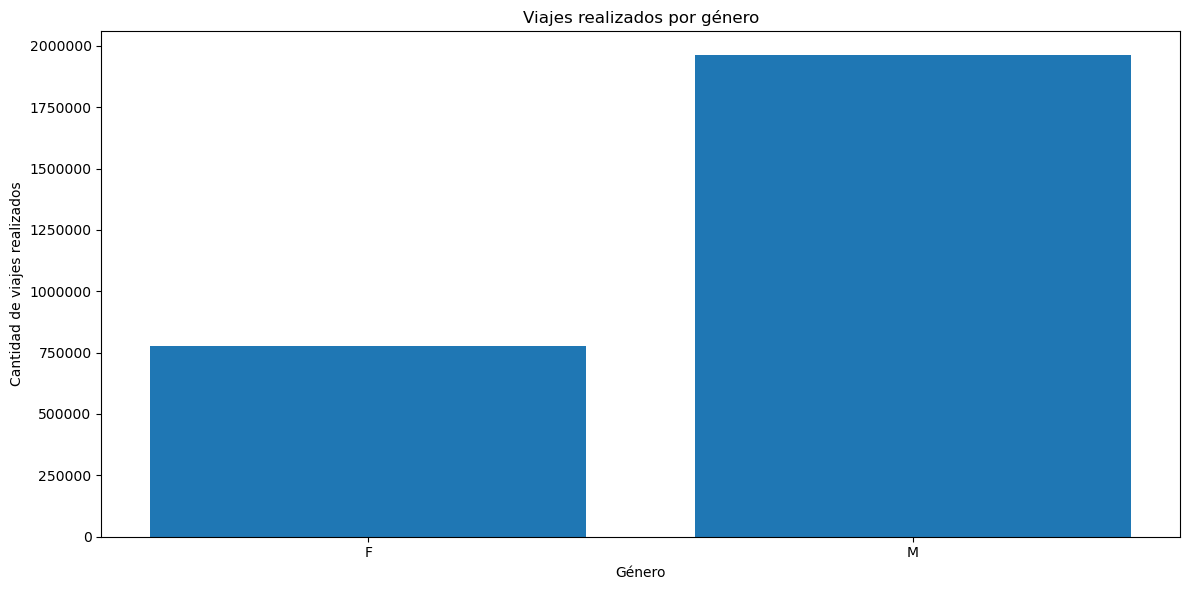

In [24]:
import matplotlib.pyplot as plt
#SIEMPRE realizar un filtro de datos antes de realizar la conversión .toPandas() para
#sólo obtener los datos que se requieren para la gráfica en lugar de el DF completo.

viajes_por_genero = df.groupBy('Genero_Usuario').count().orderBy('count',ascending=True)
print(f"Viajes por Género")

tDF=viajes_por_genero.toPandas()
plt.figure(figsize=(12,6))
plt.bar(tDF['Genero_Usuario'], tDF['count'])
plt.ticklabel_format(style='plain', axis='y')
plt.xlabel("Género")
plt.ylabel("Cantidad de viajes realizados")
plt.title("Viajes realizados por género")
plt.tight_layout()
plt.show()

El siguiente método es utilizando SQL 

+--------------+--------------+
|Genero_Usuario|Viajes_totales|
+--------------+--------------+
|F             |777068        |
|M             |1960849       |
+--------------+--------------+



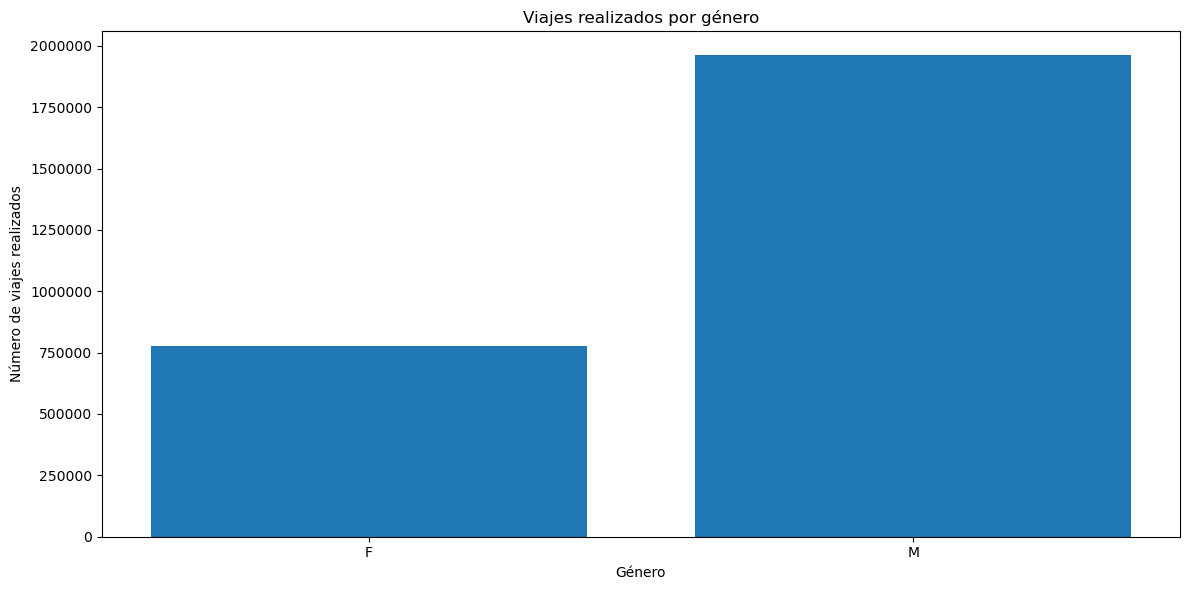

In [25]:
strsql="""
SELECT Genero_Usuario, COUNT(*) as Viajes_totales
FROM ecobici
GROUP BY Genero_Usuario
ORDER BY Viajes_totales ASC
"""
plt.figure(figsize=(12,6))
spark.sql(strsql).show(truncate=False)
tDF=spark.sql(strsql).toPandas()
plt.bar(tDF['Genero_Usuario'],tDF['Viajes_totales'])
plt.ticklabel_format(style="plain",axis='y')
plt.ylabel("Número de viajes realizados")
plt.xlabel("Género")
plt.title("Viajes realizados por género")
plt.tight_layout()
plt.show()

Como podemos observar en ambos métodos se obtienen los mismos resultados por lo que depende de preferencias personales realizar la gráfica de una u otra manera.

Además, se observa una clara tendencia en el 2012 que se realizaron más viajes por hombres que por mujeres, algo que sin duda en estos últimos años ha cambiado significativamente.

##### h) Horas pico de uso (graficación)

Realización con API de DataFrames de python

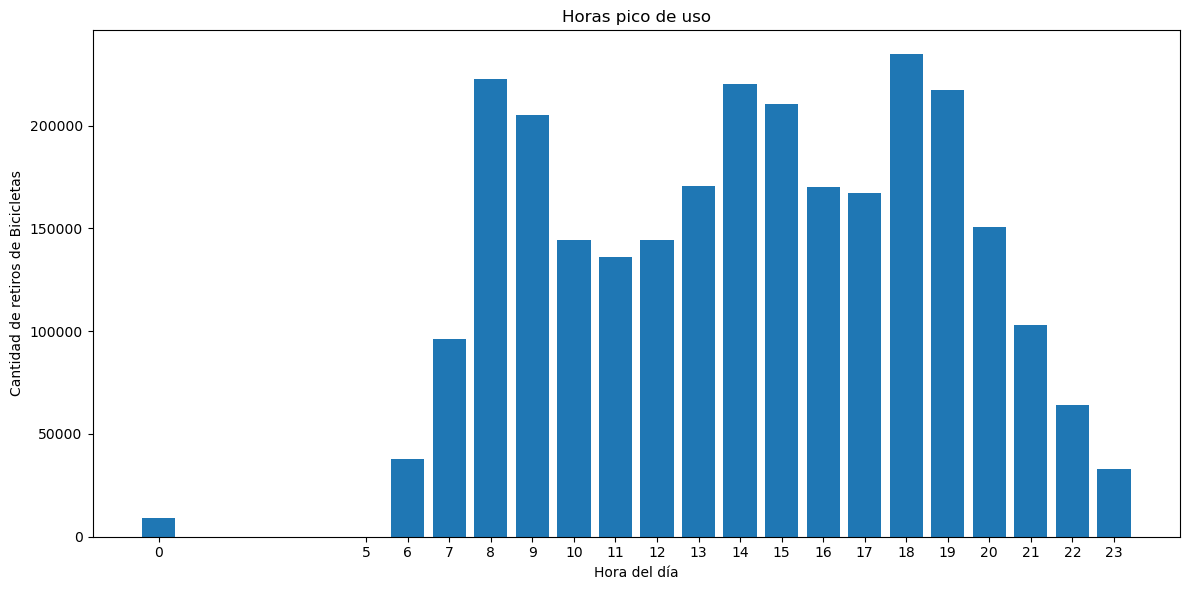

In [26]:
horas_pico = df_tiempo_retiro.groupBy("hora_retiro").count().orderBy('count', ascending=True)
tempDF=horas_pico.toPandas()

plt.figure(figsize=(12,6))
plt.bar(tempDF['hora_retiro'],tempDF['count'])
plt.xticks(tempDF['hora_retiro'])
plt.title("Horas pico de uso")
plt.ylabel("Cantidad de retiros de Bicicletas")
plt.xlabel("Hora del día")
plt.tight_layout()
plt.show()

Realización con SQL

+-----------+------+
|hora_retiro|viajes|
+-----------+------+
|          0|  9352|
|          5|    98|
|          6| 37885|
|          7| 96009|
|          8|222619|
|          9|205425|
|         10|144413|
|         11|136272|
|         12|144555|
|         13|170557|
|         14|220045|
|         15|210520|
|         16|170283|
|         17|167165|
|         18|234658|
|         19|217117|
|         20|150791|
|         21|103058|
|         22| 63961|
|         23| 33134|
+-----------+------+



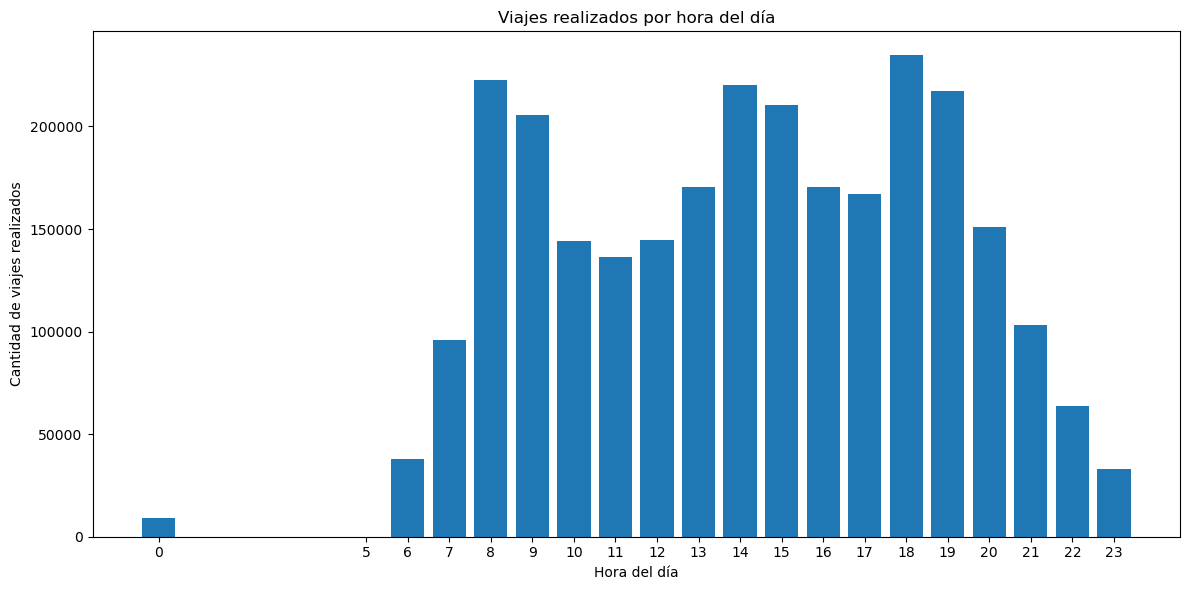

In [27]:
strsql="""
SELECT hora_retiro, COUNT(*) as viajes
FROM ecobici_retiro
GROUP BY hora_retiro
ORDER BY hora_retiro ASC
"""
spark.sql(strsql).show()
tDF = spark.sql(strsql).toPandas()
plt.figure(figsize=(12,6))
plt.bar(tDF['hora_retiro'],tDF['viajes'])
plt.xticks(tDF['hora_retiro'])
plt.xlabel('Hora del día')
plt.ylabel('Cantidad de viajes realizados')
plt.title('Viajes realizados por hora del día')
plt.tight_layout()
plt.show()

Existen tres grupos conformados por 2 horas que contienen un pico pronunciado mucho mayor que las otras 18 horas, los cuales son los siguientes 8:00 a 9:59, 14:00 a 15:59 y 18:00 a 19:59 hrs.
Dentro de estos horarios de uso sería importante evitar programar mantenimientos tanto a las estaciones como a las bicicletas ya que interfieren con horas punta.

##### i) viajes por edad de usuario (gráficación)

Realizado con API de DF de Python

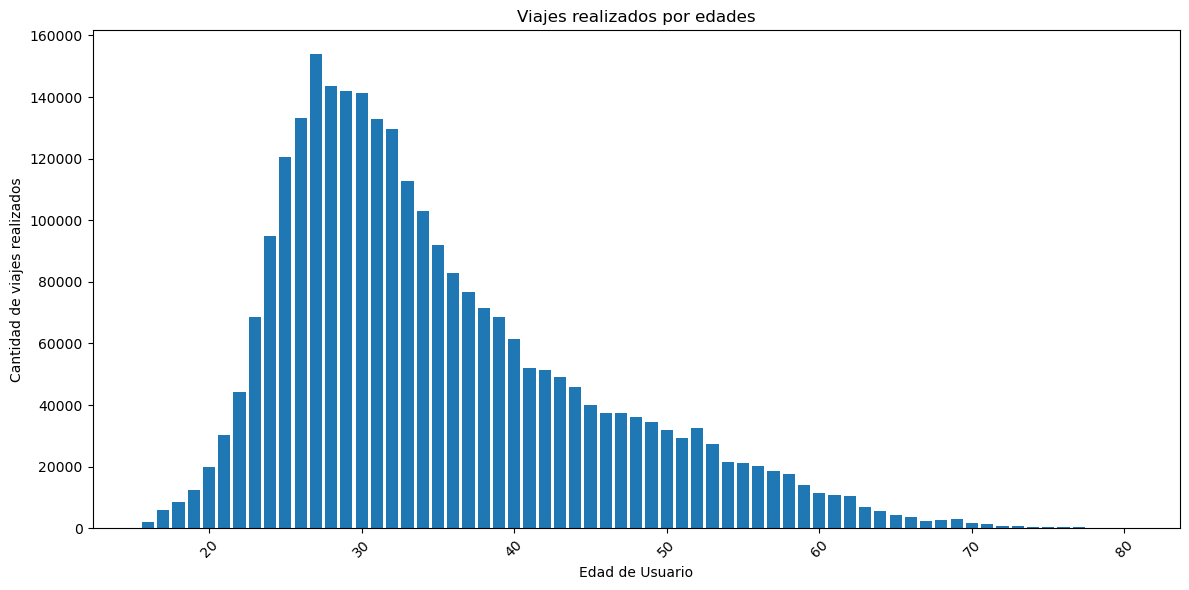

In [28]:
viajes_edad = df.groupby("Edad_Usuario").count().orderBy("count",ascending=True)
tDF = viajes_edad.toPandas()
plt.figure(figsize=(12,6))
plt.bar(tDF["Edad_Usuario"],tDF["count"])
plt.xticks(fontsize=10,rotation=45)
plt.title("Viajes realizados por edades")
plt.xlabel("Edad de Usuario")
plt.ylabel("Cantidad de viajes realizados")
plt.tight_layout()
plt.show()

Realizado con SQL

+------------+-----------+
|Edad_Usuario|viajes_edad|
+------------+-----------+
|          27|     153954|
|          28|     143514|
|          29|     141811|
|          30|     141405|
|          26|     133185|
+------------+-----------+
only showing top 5 rows



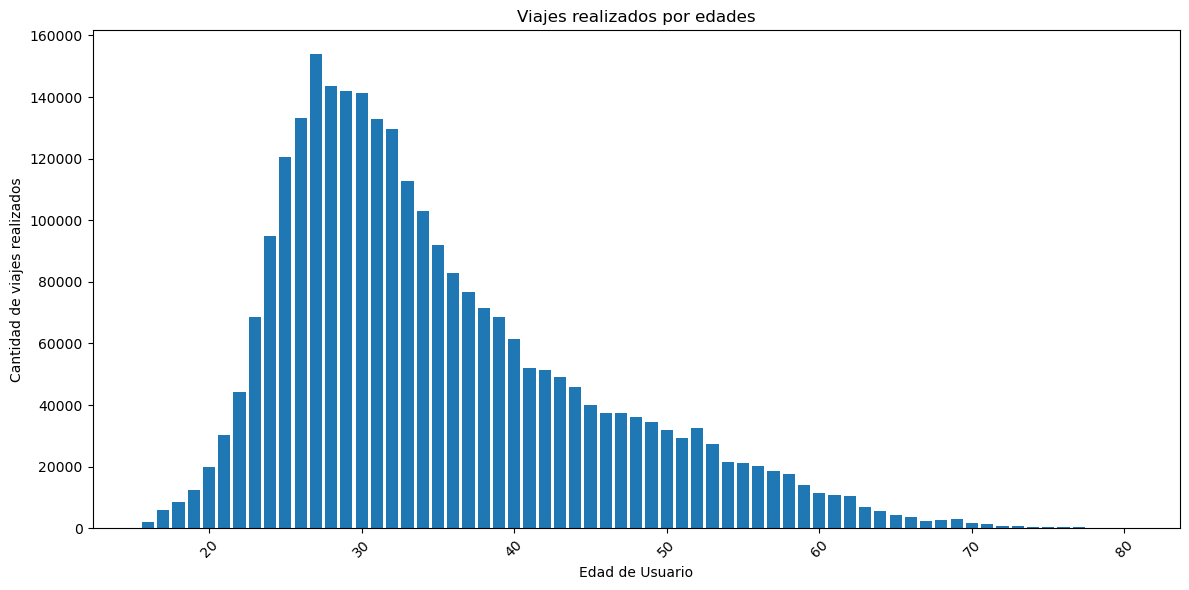

In [29]:
strsql="""
SELECT Edad_Usuario, COUNT(*) AS viajes_edad
FROM ecobici
GROUP BY Edad_Usuario
ORDER BY viajes_edad DESC
"""
spark.sql(strsql).show(5)
tDF=spark.sql(strsql).toPandas()
plt.figure(figsize=(12,6))
plt.bar(tDF["Edad_Usuario"],tDF["viajes_edad"])
plt.xticks(fontsize=10,rotation=45)
plt.title("Viajes realizados por edades")
plt.xlabel("Edad de Usuario")
plt.ylabel("Cantidad de viajes realizados")
plt.tight_layout()
plt.show()


##### j) comparativa de viajes por grupo de edad y género (graficación)

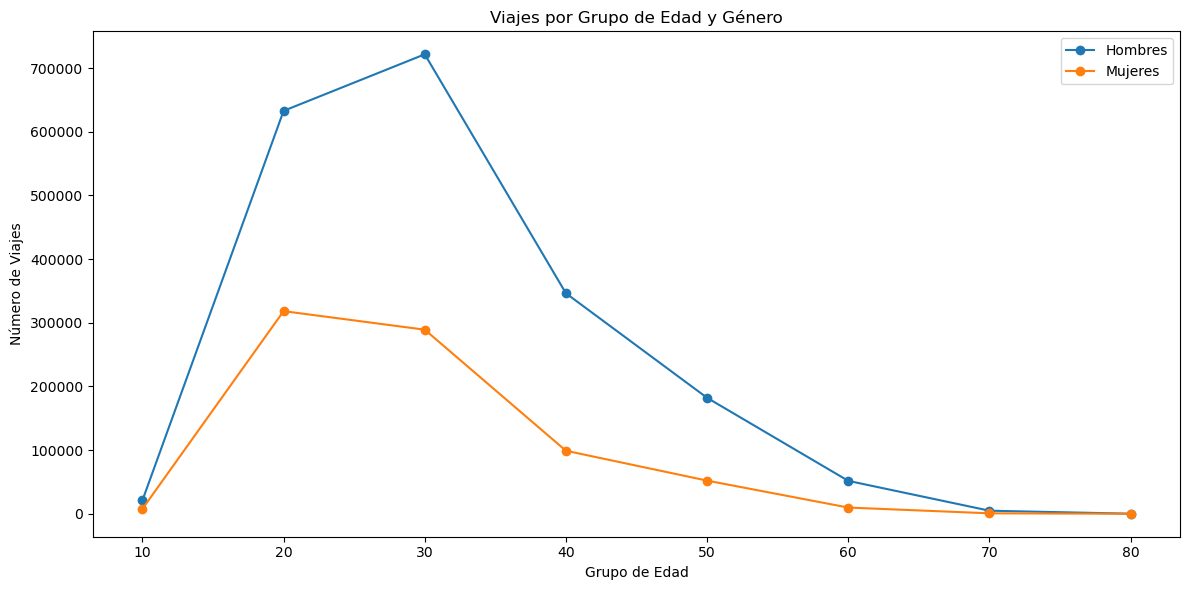

In [30]:
from pyspark.sql.functions import col, floor
#realización de grupos de edad
df_grupos = df.withColumn(
    'Grupo_Edad', (floor(col('Edad_Usuario') / 10) * 10))
#oagrupación de grupos de edad y género
viajes = df_grupos.groupBy('Grupo_Edad', 'Genero_Usuario').count().orderBy('Grupo_Edad')
tdf = viajes.toPandas()

hombres = tdf[tdf['Genero_Usuario'] == 'M']
mujeres = tdf[tdf['Genero_Usuario'] == 'F']
plt.figure(figsize=(12,6))
plt.plot(hombres['Grupo_Edad'], hombres['count'], marker='o', label='Hombres')
plt.plot(mujeres['Grupo_Edad'], mujeres['count'], marker='o', label='Mujeres')
plt.xlabel('Grupo de Edad')
plt.ylabel('Número de Viajes')
plt.title('Viajes por Grupo de Edad y Género')
plt.legend()
plt.tight_layout()
plt.show()

##### k) viajes por mes (graficación de tendencias a lo largo del año)


Realización con API de Python

In [31]:
datos_retiro.select("Fecha_Retiro").show(5, False)

+------------+
|Fecha_Retiro|
+------------+
|2012-11-01  |
|2012-11-01  |
|2012-11-01  |
|2012-11-01  |
|2012-11-01  |
+------------+
only showing top 5 rows



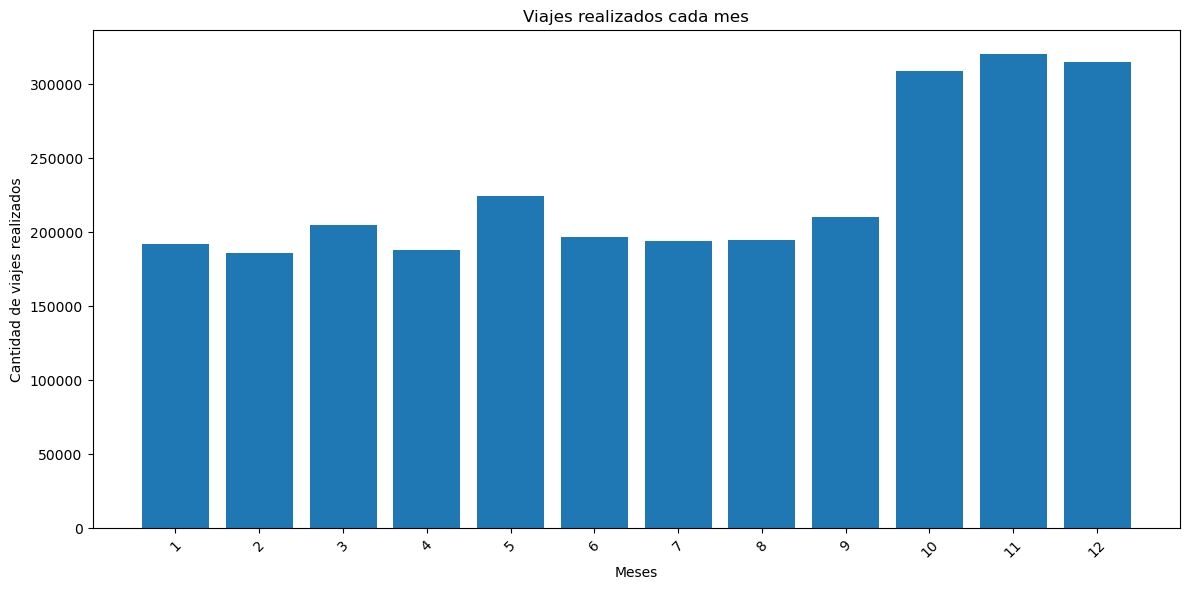

In [32]:
viajes_mes = df_tiempo_retiro.groupby("mes_retiro").count().orderBy("count", ascending = True)
tDF = viajes_mes.toPandas()

plt.figure(figsize=(12,6))
plt.bar(tDF["mes_retiro"],tDF["count"])
plt.xticks(tDF["mes_retiro"],fontsize=10,rotation=45)
plt.title("Viajes realizados cada mes")
plt.xlabel("Meses")
plt.ylabel("Cantidad de viajes realizados")
plt.tight_layout()
plt.show()

### CONCLUSIÓN

El análisis de los datos ECOBICI 2012 muestra que el sistema fue utilizado predominantemente por hombres en el rango de 20-30 años, con tres picos de uso marcados (8-9h, 14-15h, 18-19h) consistentes con traslados laborales. El mes con mayor actividad fue Noviembre (11), lo que sugiere que el clima influye directamente en el uso del sistema. Este pipeline ETL permitió procesar los datos de forma distribuida con PySpark, demostrando su viabilidad para datasets de movilidad urbana a escala, obteniendo información que es crucial para la toma de decisiones basada en datos reales por los responsables de este progrmaa